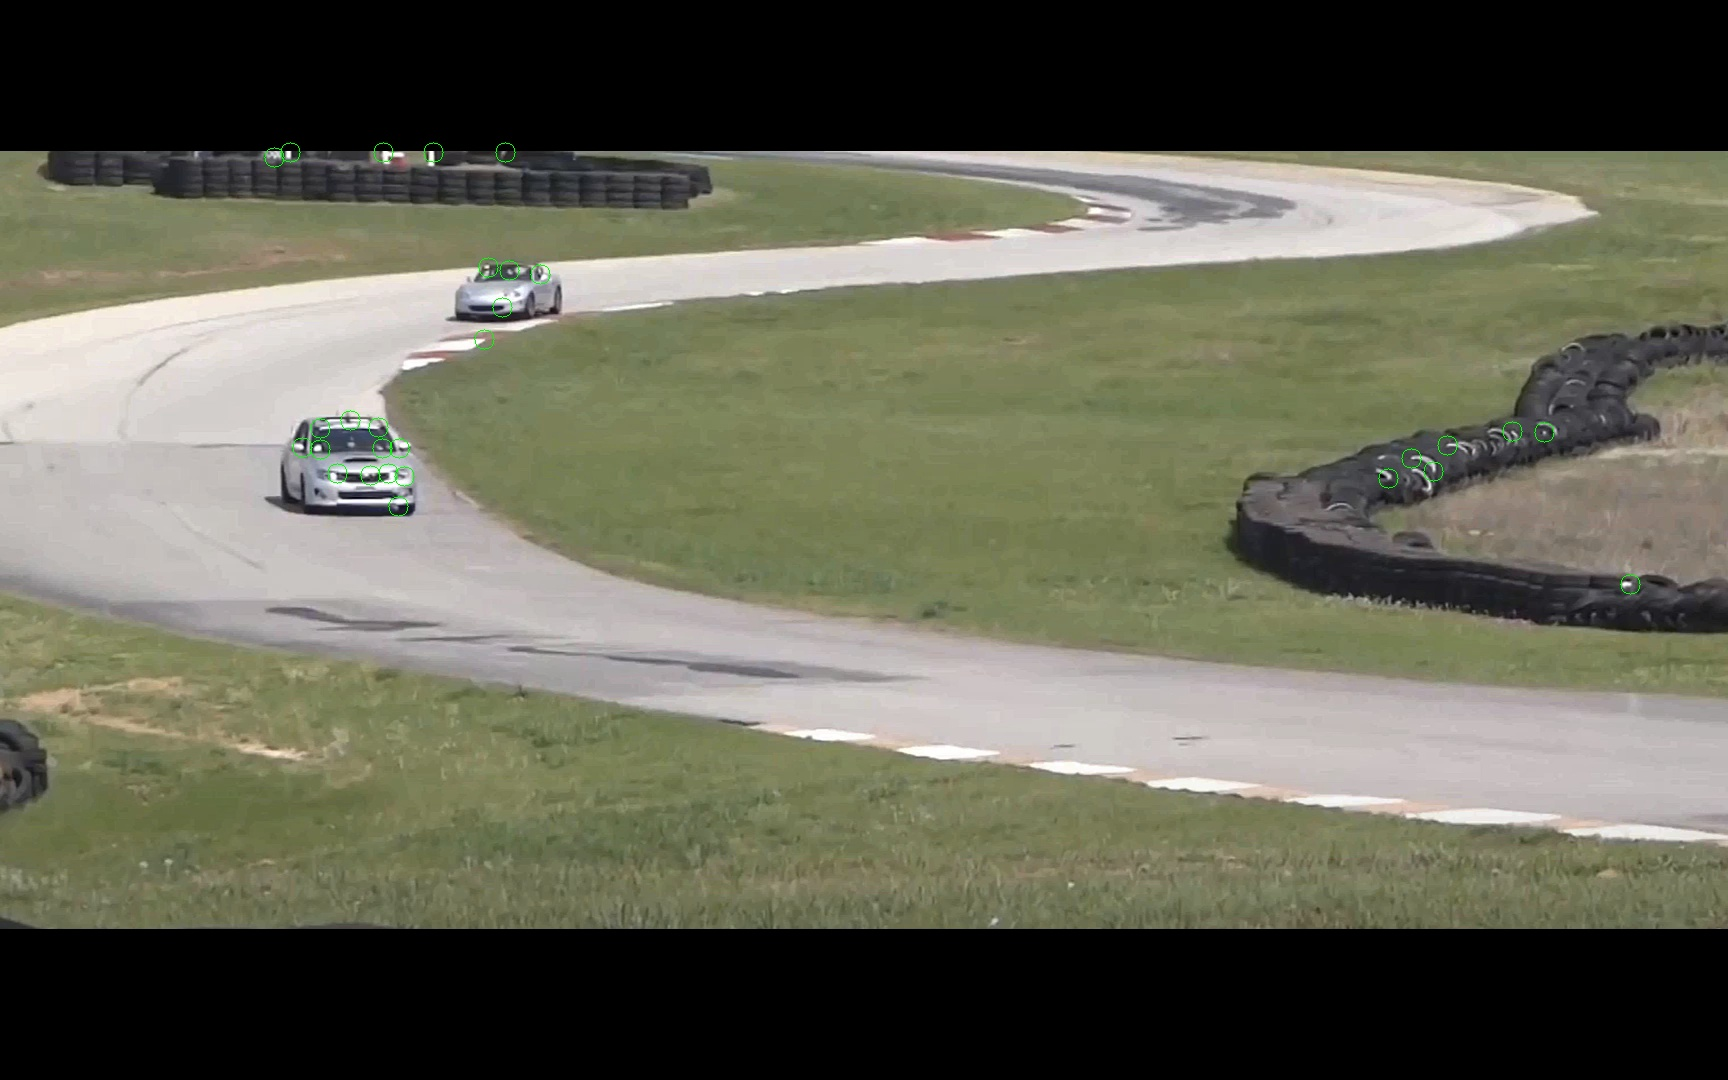

In [10]:
import numpy as np
import cv2 as cv
from IPython.display import display, Image
#--------Filter constants-----------
PREVIEW=0
BLUR=1
CANNY=2
FEATURES=3
feature_params=dict(maxCorners=500,qualityLevel=0.2,minDistance=15)
#-------Set video path an filter -------
video_path="/content/race_car.mp4"
image_filter=3
#-------- Apply filter ------
def apply_filter(frame,image_filter):
  if image_filter==PREVIEW:
    return frame
  elif image_filter==BLUR:
    return cv.blur(frame,(13,13))
  elif image_filter==CANNY:
    return cv.Canny(frame,80,150) # 80--> lowest threshold 150 -->highest threshold 150 --> pixel is definitely an edge 80 --> pixel reject an edge
  elif image_filter==FEATURES:
    result=frame.copy()
    gray=cv.cvtColor(frame,cv.COLOR_BGR2GRAY)
    corners=cv.goodFeaturesToTrack(gray,**feature_params)
    if corners is not None:
      for x,y in np.float32(corners).reshape(-1,2):
        #result --> frame to draw on, corner coordinate must b an integer , 10 --> circle radius in pixels, color--> bgr, thickness -->1
        cv.circle(result,(int(x),int(y)),10,(0,255,0),1)
    return result
  return frame
#---- Playback Loop ---
source=cv.VideoCapture(video_path)
has_frame,frame=source.read()
if has_frame:
  frame=cv.flip(frame,1)
  result=apply_filter(frame,image_filter)
  _,buf=cv.imencode(".jpg",result) # _ignore the true,false value buf stores the raw jpeg byte buffer
  display(Image(data=buf.tobytes())) #convert buffer to raw bytes, wraps it as a displayable image, renders it in a notebook cell
source.release()
